# 🧪 Streamflow Forecast Database – Exploratory Analysis

This notebook explores and validates the dataset for hydrological forecasting.
We will analyze:

1. **Data completeness** – time coverage, sampling frequency, NaN counts  
2. **Precipitation** – observed and forecast  
3. **Temperature** – observed and forecast  
4. **Solar radiation ("ray")** – observed and forecast  

At the end, we’ll discuss **potential improvements** to the dataset for use in an LSTM model with a +24h forecast horizon.


In [1]:
# Basic analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)


In [2]:
# Replace with your file path
file_path = r"..\..\data\massa_2.csv"

# Load the CSV
df = pd.read_csv(file_path)

# Display a sample
df.head()


,date,streamflow,streamflow_hindcast,streamflow_lag_1year,null_values,Unnamed: 5,hr,hr_sin,daylight,doy_sin,Unnamed: 10,prec_bruchji,prec_fieschertal,prec_jung,Unnamed: 14,temp_jungfraujoch,temp_binn,temp_eggishorn,temp_visp,temp_mean,temp_mean_6h,is_Tmean_snow,temp_mean_degree_day,Unnamed: 23,ray_jungfraujoch,ray_visp,ray_eggishorn,ray_mean,Unnamed: 28,fc_prec_bruchji,fc_prec_fieschertal,Unnamed: 31,fc_temp_jungfraujoch,fc_temp_binn,fc_temp_eggishorn,fc_temp_visp,fc_temp_mean,fc_temp_mean_6h,fc_is_Tmean_snow,fc_temp_mean_degree_day
0,01.03.2020 00:00,0.716667,0.716667,1.16,0.0,NaN,0.000000,0.000000,0.243814,0.867456,NaN,1.0,1.2,NaN,NaN,-11.132997,-1.9,-6.5,3.2,-1.733333,-2.361111,1,0.0,NaN,0.0,5.0,0.0,2.5,NaN,0.065234,0.024609,NaN,-12.621553,0.737297,-8.376507,7.101751,-0.179153,0.0,1,0.0
1,01.03.2020 01:00,0.703333,0.703333,1.16,0.0,NaN,0.017037,0.258819,0.243814,0.867813,NaN,0.4,0.7,NaN,NaN,-11.360999,-2.2,-6.4,2.1,-2.166667,-2.361111,1,0.0,NaN,0.0,4.0,0.0,2.0,NaN,0.065234,0.024609,NaN,-12.766913,0.503676,-8.427004,6.822149,-0.367060,0.0,1,0.0
2,01.03.2020 02:00,0.713333,0.713333,1.17,0.0,NaN,0.066987,0.500000,0.243814,0.868169,NaN,0.4,0.4,NaN,NaN,-11.588999,-2.1,-6.9,2.0,-2.333333,-2.361111,1,0.0,NaN,0.0,4.0,0.0,2.0,NaN,0.065234,0.024609,NaN,-12.912273,0.270055,-8.477498,6.542547,-0.554965,0.0,1,0.0
3,01.03.2020 03:00,0.710000,0.710000,1.11,0.0,NaN,0.146447,0.707107,0.243814,0.868525,NaN,0.0,0.4,NaN,NaN,-11.816998,-2.3,-7.7,1.9,-2.700000,-2.361111,1,0.0,NaN,0.0,4.0,0.0,2.0,NaN,0.065234,0.024609,NaN,-13.057632,0.036435,-8.527994,6.262945,-0.742871,0.0,1,0.0
4,01.03.2020 04:00,0.696667,0.696667,1.11,0.0,NaN,0.250000,0.866025,0.243814,0.868880,NaN,0.0,0.0,NaN,NaN,-12.044997,-2.3,-7.5,1.8,-2.666667,-2.361111,1,0.0,NaN,0.0,4.0,0.0,2.0,NaN,0.065234,0.024609,NaN,-13.202993,-0.197186,-8.578491,5.983343,-0.930778,0.0,1,0.0


In [3]:
# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Sort by date just in case
df = df.sort_values('date')

# Basic info
print("Data range:", df['date'].min(), "→", df['date'].max())
print("Number of records:", len(df))

# Check frequency (time delta mode)
time_diffs = df['date'].diff().dt.total_seconds() / 3600
print("\nApprox sampling frequency (h):", time_diffs.mode()[0])
print("Unique time deltas (h):", time_diffs.value_counts().head())

# Missing date count
missing_dates = df['date'].isna().sum()
print("\nMissing date entries:", missing_dates)


Data range: 2020-01-03 00:00:00 → 2025-12-07 23:00:00
Number of records: 47751

Approx sampling frequency (h): 1.0
Unique time deltas (h): date
1.0      18903
457.0       30
433.0       16
505.0        6
553.0        6
Name: count, dtype: int64

Missing date entries: 28776


,Missing Values,Missing %
Unnamed: 10,47751,100.0
Unnamed: 14,47751,100.0
Unnamed: 23,47751,100.0
Unnamed: 28,47751,100.0
Unnamed: 31,47751,100.0
Unnamed: 5,47751,100.0
date,28776,60.0
daylight,0,0.0
doy_sin,0,0.0
fc_is_Tmean_snow,0,0.0


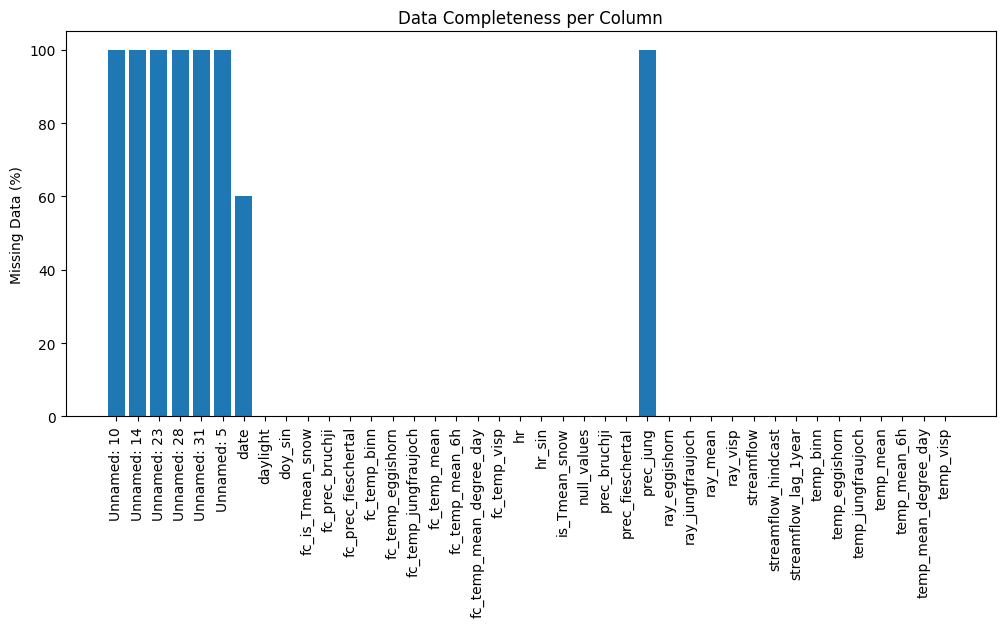

In [4]:
# Count missing values per column
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_pct = 100 * df.isna().mean().round(2)

# Combine into one table
completeness = pd.DataFrame({
    'Missing Values': missing_summary,
    'Missing %': missing_pct
})

display(completeness)

# Quick visual of missing data
plt.figure(figsize=(12, 5))
plt.bar(completeness.index, completeness['Missing %'])
plt.xticks(rotation=90)
plt.ylabel("Missing Data (%)")
plt.title("Data Completeness per Column")
plt.show()


Precipitation columns: ['prec_bruchji', 'prec_fieschertal', 'prec_jung', 'fc_prec_bruchji', 'fc_prec_fieschertal']


,count,mean,std,min,25%,50%,75%,max
prec_bruchji,47751.0,0.121143,0.482377,0.0,0.0,0.0,0.000000,18.700001
prec_fieschertal,47751.0,0.110685,0.530210,0.0,0.0,0.0,0.000000,20.000000
prec_jung,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fc_prec_bruchji,47751.0,0.273417,1.072114,0.0,0.0,0.0,0.025000,28.178909
fc_prec_fieschertal,47751.0,0.121040,0.519100,0.0,0.0,0.0,0.007959,22.771877


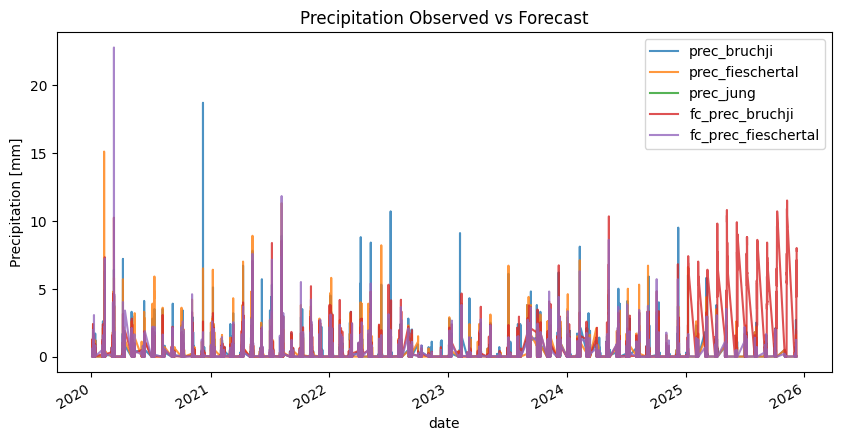


Precipitation Data Completeness (%):
 prec_bruchji           100.0
prec_fieschertal       100.0
prec_jung                0.0
fc_prec_bruchji        100.0
fc_prec_fieschertal    100.0
dtype: float64


In [5]:
prec_cols = [c for c in df.columns if 'prec' in c.lower()]

print("Precipitation columns:", prec_cols)

prec_stats = df[prec_cols].describe().T
display(prec_stats)

# Plot example
df.set_index('date')[prec_cols].plot(title='Precipitation Observed vs Forecast', alpha=0.8)
plt.ylabel("Precipitation [mm]")
plt.show()

# Completeness
prec_completeness = df[prec_cols].notna().mean() * 100
print("\nPrecipitation Data Completeness (%):\n", prec_completeness.round(1))


Measured temperature cols: ['temp_jungfraujoch', 'temp_binn', 'temp_eggishorn', 'temp_visp', 'temp_mean', 'temp_mean_6h', 'temp_mean_degree_day']
Forecast temperature cols: ['fc_temp_jungfraujoch', 'fc_temp_binn', 'fc_temp_eggishorn', 'fc_temp_visp', 'fc_temp_mean', 'fc_temp_mean_6h', 'fc_temp_mean_degree_day']


,count,mean,std,min,25%,50%,75%,max
temp_jungfraujoch,47751.0,-5.662414,6.466851,-26.033333,-10.283333,-5.283333,-0.700000,11.166667
temp_binn,47751.0,7.072994,7.663212,-14.600000,1.200000,6.600000,12.500000,30.466667
temp_eggishorn,47751.0,-0.749692,6.697496,-20.200001,-5.600000,-0.640959,4.100000,18.833332
temp_visp,47751.0,11.229099,8.920808,-14.700000,4.400000,11.200000,17.500000,35.599998
temp_mean,47751.0,5.850800,7.417733,-15.200000,0.133333,5.500000,11.266666,27.816667
temp_mean_6h,47751.0,5.849466,7.318842,-14.772222,0.183333,5.499487,11.288889,26.896296
temp_mean_degree_day,47751.0,160.208033,140.253040,0.000000,22.433334,132.566667,279.300001,520.213889


,count,mean,std,min,25%,50%,75%,max
fc_temp_jungfraujoch,47751.0,-6.091752,6.474600,-26.132475,-10.744365,-5.916116,-0.946594,9.005354
fc_temp_binn,47751.0,7.122206,7.372751,-13.701889,1.481945,6.744828,12.495621,28.756269
fc_temp_eggishorn,47751.0,-0.866993,6.974018,-20.411577,-6.054914,-1.202885,4.514562,17.974659
fc_temp_visp,47751.0,12.661623,7.962596,-7.409204,6.547766,12.219336,18.247000,37.307865
fc_temp_mean,47751.0,6.305612,7.350444,-13.723642,0.740061,5.878885,11.680434,27.940147
fc_temp_mean_6h,47751.0,6.304318,7.261031,-13.429283,0.789102,5.930427,11.725126,26.674966
fc_temp_mean_degree_day,47751.0,168.275352,142.464303,0.000000,29.188129,144.169958,290.990958,515.239817


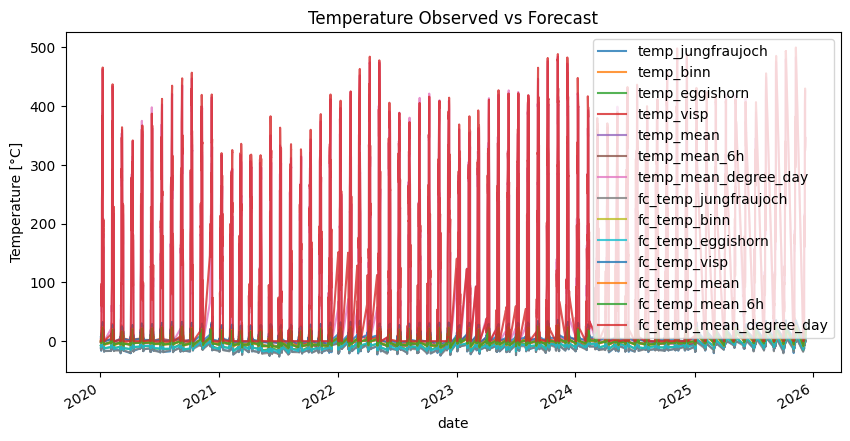


Observed Temperature Completeness (%):
 temp_jungfraujoch       100.0
temp_binn               100.0
temp_eggishorn          100.0
temp_visp               100.0
temp_mean               100.0
temp_mean_6h            100.0
temp_mean_degree_day    100.0
dtype: float64

Forecast Temperature Completeness (%):
 fc_temp_jungfraujoch       100.0
fc_temp_binn               100.0
fc_temp_eggishorn          100.0
fc_temp_visp               100.0
fc_temp_mean               100.0
fc_temp_mean_6h            100.0
fc_temp_mean_degree_day    100.0
dtype: float64


In [6]:
temp_cols = [c for c in df.columns if 'temp' in c.lower() and not c.startswith('fc_')]
fc_temp_cols = [c for c in df.columns if 'fc_temp' in c.lower()]

print("Measured temperature cols:", temp_cols)
print("Forecast temperature cols:", fc_temp_cols)

# Descriptive stats
temp_stats = df[temp_cols].describe().T
fc_temp_stats = df[fc_temp_cols].describe().T

display(temp_stats)
display(fc_temp_stats)

# Plot comparison
df.set_index('date')[temp_cols + fc_temp_cols].plot(alpha=0.8)
plt.ylabel("Temperature [°C]")
plt.title("Temperature Observed vs Forecast")
plt.show()

# Completeness
temp_completeness = df[temp_cols].notna().mean() * 100
fc_temp_completeness = df[fc_temp_cols].notna().mean() * 100

print("\nObserved Temperature Completeness (%):\n", temp_completeness.round(1))
print("\nForecast Temperature Completeness (%):\n", fc_temp_completeness.round(1))


Radiation columns: ['ray_jungfraujoch', 'ray_visp', 'ray_eggishorn', 'ray_mean']


,count,mean,std,min,25%,50%,75%,max
ray_jungfraujoch,47751.0,190.150814,284.047585,0.0,0.0,8.333333,312.012497,1245.666626
ray_visp,47751.0,176.576436,272.104739,0.0,4.0,11.000000,263.166672,1151.000000
ray_eggishorn,47751.0,177.646873,256.362353,0.0,0.0,10.000000,305.000000,1207.000000
ray_mean,47751.0,174.056627,254.662356,0.0,2.0,11.500000,276.000000,1136.500000


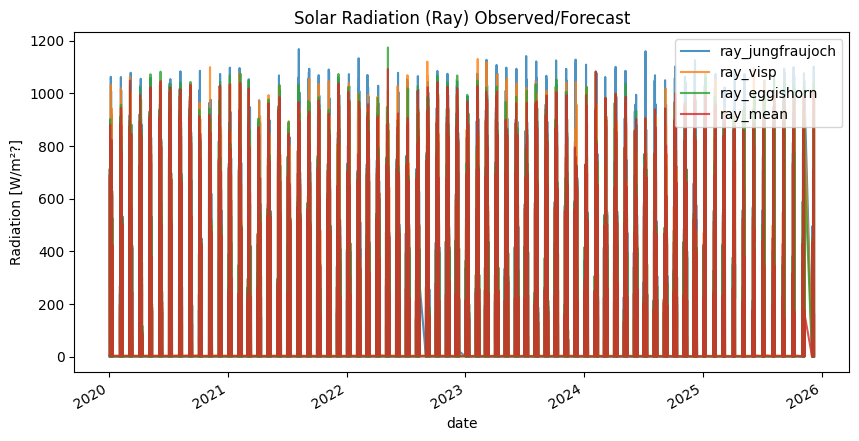


Radiation Completeness (%):
 ray_jungfraujoch    100.0
ray_visp            100.0
ray_eggishorn       100.0
ray_mean            100.0
dtype: float64


In [7]:
ray_cols = [c for c in df.columns if 'ray' in c.lower()]
print("Radiation columns:", ray_cols)

ray_stats = df[ray_cols].describe().T
display(ray_stats)

df.set_index('date')[ray_cols].plot(title="Solar Radiation (Ray) Observed/Forecast", alpha=0.8)
plt.ylabel("Radiation [W/m²?]")
plt.show()

# Completeness
ray_completeness = df[ray_cols].notna().mean() * 100
print("\nRadiation Completeness (%):\n", ray_completeness.round(1))


Streamflow columns: ['streamflow', 'streamflow_hindcast', 'streamflow_lag_1year']


,count,mean,std,min,25%,50%,75%,max
streamflow,47751.0,17.922127,23.226368,0.263333,0.731,4.785,32.964248,126.3705
streamflow_hindcast,47751.0,17.922127,23.226368,0.263333,0.731,4.785,32.964248,126.3705
streamflow_lag_1year,47751.0,18.111944,23.610392,0.263333,0.816,4.170,33.507500,126.3705


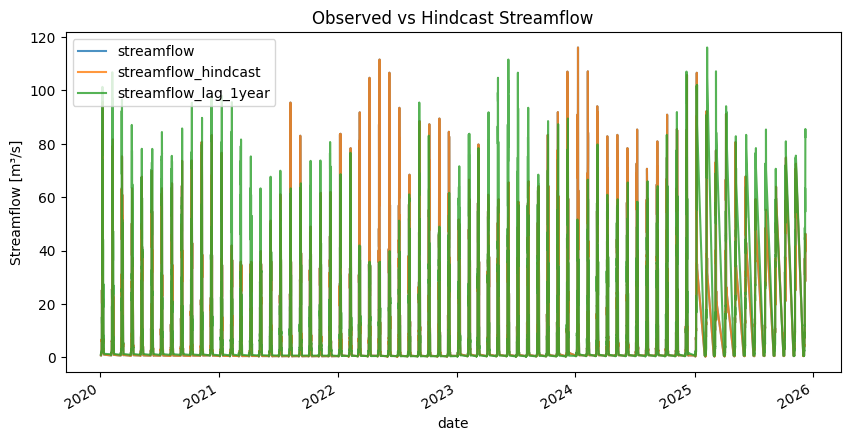


Streamflow Completeness (%):
 streamflow              100.0
streamflow_hindcast     100.0
streamflow_lag_1year    100.0
dtype: float64


In [8]:
stream_cols = [c for c in df.columns if 'streamflow' in c.lower()]
print("Streamflow columns:", stream_cols)

stream_stats = df[stream_cols].describe().T
display(stream_stats)

df.set_index('date')[stream_cols].plot(title="Observed vs Hindcast Streamflow", alpha=0.8)
plt.ylabel("Streamflow [m³/s]")
plt.show()

stream_completeness = df[stream_cols].notna().mean() * 100
print("\nStreamflow Completeness (%):\n", stream_completeness.round(1))


In [9]:
summary = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Std': df.std(numeric_only=True),
    'Min': df.min(numeric_only=True),
    'Max': df.max(numeric_only=True),
    'Completeness (%)': df.notna().mean() * 100
}).round(2)

display(summary)


,Mean,Std,Min,Max,Completeness (%)
Unnamed: 10,NaN,NaN,NaN,NaN,0.00
Unnamed: 14,NaN,NaN,NaN,NaN,0.00
Unnamed: 23,NaN,NaN,NaN,NaN,0.00
Unnamed: 28,NaN,NaN,NaN,NaN,0.00
Unnamed: 31,NaN,NaN,NaN,NaN,0.00
Unnamed: 5,NaN,NaN,NaN,NaN,0.00
date,NaN,NaN,NaN,NaN,39.74
daylight,0.52,0.35,0.00,1.00,100.00
doy_sin,0.04,0.71,-1.00,1.00,100.00
fc_is_Tmean_snow,0.22,0.41,0.00,1.00,100.00


# 🚀 Upgrade Ideas for LSTM Hindcast/Forecast Modeling (+24h Horizon)

To improve data quality and model readiness:

### Data Quality
- Ensure **consistent hourly or 6-hourly resolution** across all features  
- Fill or interpolate **short gaps (<6h)**, mark long missing periods as masked inputs  
- Verify **temporal alignment** between observations and forecasts (no leakage)

### Feature Engineering
- Compute **lag features** (e.g., precipitation or temp at t−6h, t−12h, t−24h)  
- Derive **cumulative precipitation** and **moving average temperatures**  
- Add **seasonal features** – day of year, sine/cosine encoding for seasonality  
- Create **snowmelt indicators** using temperature thresholds and degree days  

### Model Input Structuring
- Split dataset into **hindcast input (past N hours)** and **forecast target (+24h streamflow)**  
- Normalize each feature (mean/std or min-max scaling)
- Check correlation between inputs (precip/temp/ray) and target (streamflow)

### Potential Future Data Additions
- Include **soil moisture or snow depth sensors**  
- Add **wind speed, humidity**, or **pressure** as additional meteo predictors  
- If available, integrate **remote-sensing or reanalysis data** (e.g., ERA5, IMERG)

---
**Goal:** Maximize physical signal and temporal consistency before LSTM training.


# 🔍 Hindcast Window Estimation Tool

This section estimates the optimal **hindcast length** — the number of past timesteps
needed to predict streamflow 24 hours ahead.

We use correlation analysis between streamflow and its potential drivers
(precipitation, temperature, radiation) at various time lags.


C:\Users\Kohler\AppData\Local\Temp\ipykernel_21336\148454350.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x_temp = df[temp_cols[0]].fillna(method='ffill')
C:\Users\Kohler\AppData\Local\Temp\ipykernel_21336\148454350.py:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  x_ray = df[ray_cols[0]].fillna(method='ffill')


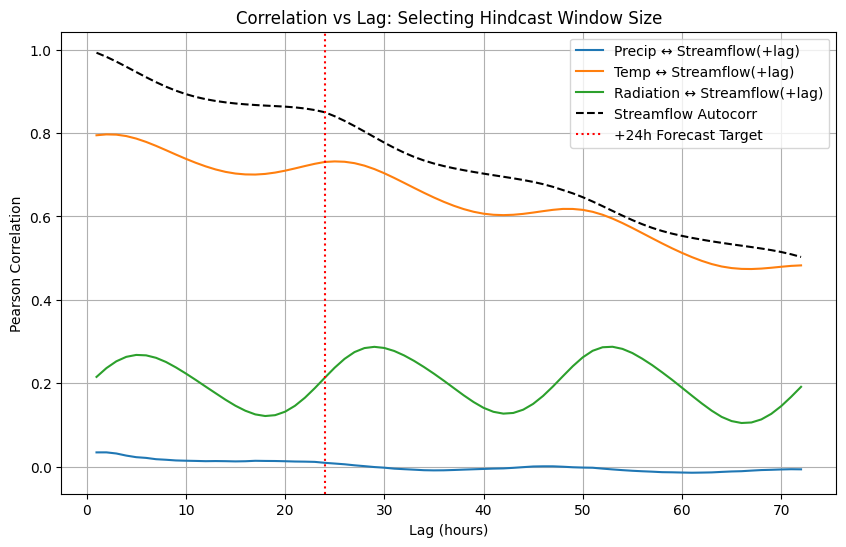

🔹 Suggested hindcast length: ~0 hours based on autocorrelation peak


In [10]:
from scipy.stats import pearsonr

# Ensure datetime index
df = df.set_index('date').sort_index()

# Define key variable groups
stream_col = [c for c in df.columns if 'streamflow' in c.lower() and 'hindcast' not in c.lower()]
prec_cols = [c for c in df.columns if 'prec' in c.lower()]
temp_cols = [c for c in df.columns if 'temp_mean' in c.lower() and not c.startswith('fc_')]
ray_cols = [c for c in df.columns if 'ray_mean' in c.lower()]

# Select representative columns (adjust if needed)
y = df[stream_col[0]].dropna()
# old way
x_prec = df[prec_cols[0]].fillna(0)
# new way
# x_pre
# old way
x_temp = df[temp_cols[0]].fillna(method='ffill')
# # new way
# x_temp = df[temp_cols[0]].ffill()

x_ray = df[ray_cols[0]].fillna(method='ffill')

# Define lag range (hours)
max_lag = 72  # up to 3 days
lags = range(1, max_lag + 1)

corr_results = {'lag_hours': [], 'prec_corr': [], 'temp_corr': [], 'ray_corr': [], 'auto_corr': []}

for lag in lags:
    shifted = y.shift(-lag)  # streamflow 24h ahead
    valid = y.notna() & shifted.notna()

    if valid.sum() > 50:
        corr_results['lag_hours'].append(lag)
        corr_results['prec_corr'].append(pearsonr(x_prec[valid], shifted[valid])[0])
        corr_results['temp_corr'].append(pearsonr(x_temp[valid], shifted[valid])[0])
        corr_results['ray_corr'].append(pearsonr(x_ray[valid], shifted[valid])[0])
        corr_results['auto_corr'].append(pearsonr(y[valid], shifted[valid])[0])

# Convert to DataFrame
corr_df = pd.DataFrame(corr_results)

# Plot correlations vs lag
plt.figure(figsize=(10, 6))
plt.plot(corr_df['lag_hours'], corr_df['prec_corr'], label='Precip ↔ Streamflow(+lag)')
plt.plot(corr_df['lag_hours'], corr_df['temp_corr'], label='Temp ↔ Streamflow(+lag)')
plt.plot(corr_df['lag_hours'], corr_df['ray_corr'], label='Radiation ↔ Streamflow(+lag)')
plt.plot(corr_df['lag_hours'], corr_df['auto_corr'], label='Streamflow Autocorr', linestyle='--', color='black')
plt.axvline(24, color='red', linestyle=':', label='+24h Forecast Target')
plt.xlabel("Lag (hours)")
plt.ylabel("Pearson Correlation")
plt.title("Correlation vs Lag: Selecting Hindcast Window Size")
plt.legend()
plt.grid(True)
plt.show()

# Suggest hindcast window
suggested_lag = int(corr_df['auto_corr'].idxmax())
print(f"🔹 Suggested hindcast length: ~{suggested_lag} hours based on autocorrelation peak")
